[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter2_seminar_notebook.ipynb)

# Time Series Analysis — Seminar 2: ARMA models

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 2; the slides give the formulas ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_2'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- Helpers of Chapter 2 (`fit_arma`, `ljung_box`, `acf_bars`, `psi_weights`, `inverse_roots`, `ro_gdp_growth`, `ro_inflation`) and the seminar functions: `ar1_facts`, `ma1_facts`, `yw_ar2`, `ic_table`, `box_jenkins`, `b1_us_gdp`, `b3_returns`.

In [ ]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.regression.linear_model import yule_walker
SEED = 2026
GDP_NSA = ('namq_10_gdp', 'Q.CLV10_MEUR.NSA.B1GQ.RO')
GDP_SCA = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')
GDP_START = '2000-01-01'
INFL_START = '2005-01-01'
BAND_COL = st.IDAred
MODELS = {'AR(2)': ([1.0, -0.6], []), 'MA(2)': ([], [0.6, 0.3]), 'ARMA(1,1)': ([0.7], [0.4])}
HERE = "."


def ro_gdp_growth(kind='yoy', start=GDP_START):
    """Romanian real GDP growth in %: 'yoy' = 100 (ln Y_t - ln Y_{t-4}) of the unadjusted series,
    'qoq' = 100 (ln Y_t - ln Y_{t-1}) of the seasonally adjusted series."""
    if kind == 'yoy':
        y = 100 * np.log(read_eurostat(*GDP_NSA)).diff(4)
    else:
        y = 100 * np.log(read_eurostat(*GDP_SCA)).diff()
    y = y.dropna().loc[start:]
    y.index.freq = None
    return y.rename(f'gdp_{kind}')


def ro_inflation(start=INFL_START):
    """Romanian 12-month HICP inflation in %: 100 (ln P_t - ln P_{t-12})."""
    p = read_eurostat(*HICP)
    return (100 * np.log(p).diff(12)).dropna().loc[start:].rename('inflation')


def sample_acf(x, nlags=20):
    """Sample ACF rho(1..nlags) with the divisor T (Chapter 1)."""
    return acf(np.asarray(x, float), nlags=nlags, fft=True)[1:]


def sample_pacf(x, nlags=20):
    """Sample PACF phi_hh, h = 1..nlags (Durbin-Levinson on the sample ACF)."""
    return pacf(np.asarray(x, float), nlags=nlags, method='ywm')[1:]


def ljung_box(x, m=10, df=None):
    """Ljung-Box Q*(m) with its p-value from chi2(df); df = m by default, m - p - q for ARMA residuals."""
    x = np.asarray(x, float)
    T = len(x)
    r = sample_acf(x, m)
    q = T * (T + 2) * np.sum(r ** 2 / (T - np.arange(1, m + 1)))
    df = m if df is None else df
    return {'lb': float(q), 'df': int(df), 'lb_p': float(stats.chi2.sf(q, df))}


def acf_bars(ax, r, T, color=st.MainBlue, theory=None, label='sample', band=True, theory_label='theoretical'):
    """Bars at lags 1..len(r), the +-1.96/sqrt(T) band and optional theoretical values (dots)."""
    lags = np.arange(1, len(r) + 1)
    ax.bar(lags, r, width=0.55, color=color, label=label)
    if theory is not None:
        ax.plot(lags, theory, 'o', ms=4, color=st.Orange, label=theory_label)
    if band:
        b = 1.96 / np.sqrt(T)
        ax.axhline(b, color=BAND_COL, ls='--', lw=0.9, label=r'$\pm 1.96/\sqrt{T}$')
        ax.axhline(-b, color=BAND_COL, ls='--', lw=0.9, label='_nolegend_')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xlim(0.3, len(r) + 0.7)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))


def simulate_arma(phi=(), theta=(), n=500, sigma=1.0, mu=0.0, burn=500, rng=None):
    """X_t - mu = sum phi_i (X_{t-i} - mu) + e_t + sum theta_j e_{t-j}, e_t i.i.d. N(0, sigma^2), after a burn-in."""
    rng = rng if rng is not None else np.random.default_rng(SEED)
    e = rng.normal(0, sigma, n + burn)
    x = np.zeros(n + burn)
    p, q = len(phi), len(theta)
    for t in range(n + burn):
        x[t] = e[t] + sum(phi[i] * x[t - 1 - i] for i in range(p) if t - 1 - i >= 0) \
            + sum(theta[j] * e[t - 1 - j] for j in range(q) if t - 1 - j >= 0)
    return mu + x[burn:]


def arma_process(phi=(), theta=()):
    """statsmodels ArmaProcess for X_t = phi_1 X_{t-1} + ... + e_t + theta_1 e_{t-1} + ... (signs as in the slides)."""
    return ArmaProcess(np.r_[1, -np.asarray(phi, float)], np.r_[1, np.asarray(theta, float)])


def theoretical_acf(phi=(), theta=(), nlags=20):
    return arma_process(phi, theta).acf(nlags + 1)[1:]


def theoretical_pacf(phi=(), theta=(), nlags=20):
    return arma_process(phi, theta).pacf(nlags + 1)[1:]


def psi_weights(phi=(), theta=(), n=20):
    """psi_0, ..., psi_{n-1} of the causal representation X_t = sum psi_j e_{t-j}:
    psi_j = theta_j + sum_{i=1}^{min(j,p)} phi_i psi_{j-i}, psi_0 = 1."""
    p, q = len(phi), len(theta)
    psi = np.zeros(n)
    psi[0] = 1.0
    for j in range(1, n):
        psi[j] = (theta[j - 1] if j <= q else 0.0) + sum(phi[i] * psi[j - 1 - i] for i in range(min(j, p)))
    return psi


def inverse_roots(phi):
    """Inverse roots of 1 - phi_1 z - ... - phi_p z^p (stationary iff all have modulus < 1)."""
    roots = np.roots(np.r_[-np.asarray(phi, float)[::-1], 1.0])
    return 1 / roots


def fit_arma(x, p, q, trend='c'):
    """Gaussian maximum likelihood (statsmodels state-space ARIMA)."""
    return ARIMA(np.asarray(x, float), order=(p, 0, q), trend=trend).fit()


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def ar1_facts(c, phi, sigma2, x_T, H=3):
    """AR(1) X_t = c + phi X_{t-1} + e_t: mean, variance, ACF, psi weights, forecasts, forecast MSE and 95% intervals."""
    mu = c / (1 - phi)
    h = np.arange(1, H + 1)
    f = mu + phi ** h * (x_T - mu)
    mse = sigma2 * np.cumsum(phi ** (2 * np.arange(H)))
    return {'mu': mu, 'gamma0': sigma2 / (1 - phi ** 2), 'rho': [phi ** k for k in range(1, 4)],
            'psi': [phi ** k for k in range(4)], 'f': f.tolist(), 'mse': mse.tolist(),
            'lo': (f - 1.96 * np.sqrt(mse)).tolist(), 'hi': (f + 1.96 * np.sqrt(mse)).tolist(),
            'half_life': float(np.log(0.5) / np.log(abs(phi)))}


def ma1_facts(theta, sigma2):
    """MA(1): gamma(0), gamma(1), rho(1); the invertible twin (1/theta, theta^2 sigma^2) with the same autocovariances."""
    g0, g1 = sigma2 * (1 + theta ** 2), sigma2 * theta
    t2, s2 = 1 / theta, theta ** 2 * sigma2
    return {'g0': g0, 'g1': g1, 'rho1': g1 / g0, 'theta_inv': t2, 'sigma2_inv': s2, 'g0_inv': s2 * (1 + t2 ** 2),
            'g1_inv': s2 * t2, 'pi': [(-t2) ** j for j in range(4)]}


def yw_ar2(r1, r2, g0):
    """Yule-Walker estimates of an AR(2) from rho(1), rho(2) and gamma(0)."""
    det = 1 - r1 ** 2
    p1 = (r1 - r1 * r2) / det
    p2 = (r2 - r1 ** 2) / det
    return {'det': det, 'phi1': p1, 'phi2': p2, 'sigma2': g0 * (1 - p1 * r1 - p2 * r2), 'cond': [p1 + p2, p2 - p1, p2]}


def ic_table(loglik, k, T):
    """AIC = -2 lnL + 2k and BIC = -2 lnL + k ln T for several models (dict name -> log-likelihood)."""
    return {m: {'aic': -2 * l + 2 * k[m], 'bic': -2 * l + k[m] * np.log(T)} for m, l in loglik.items()}


def box_jenkins(y, name, fname=None, save=True, orders=((0, 0), (1, 0), (2, 0), (0, 2), (1, 1)), m=8, color=st.MainBlue):
    """Identification (ACF, PACF), estimation of several ARMA models by ML, AIC/BIC, Ljung-Box on the residuals of the
    BIC model with m - p - q degrees of freedom, Jarque-Bera."""
    y = pd.Series(np.asarray(y, float), index=getattr(y, 'index', None))
    T = len(y)
    r, pc = sample_acf(y, 12), sample_pacf(y, 12)
    rows = {}
    for p, q in orders:
        f = fit_arma(y.values, p, q)
        rows[f'ARMA({p},{q})'] = {'p': p, 'q': q, 'params': [float(v) for v in f.params], 'se': [float(v) for v in f.bse],
                                  'aic': float(f.aic), 'bic': float(f.bic), 'loglik': float(f.llf)}
    best = min(rows, key=lambda k: rows[k]['bic'])
    besta = min(rows, key=lambda k: rows[k]['aic'])
    p, q = rows[best]['p'], rows[best]['q']
    e = fit_arma(y.values, p, q).resid[max(p, q):]
    jb = stats.jarque_bera(e)
    if fname:
        fig, ax = plt.subplots(1, 3, figsize=(11.0, 3.1), gridspec_kw={'width_ratios': [1.6, 1, 1]})
        ax[0].plot(y.index, y.values, color=color, lw=1)
        ax[0].axhline(y.mean(), color=st.Orange, ls='--', lw=1, label='sample mean')
        ax[0].set_title(name)
        acf_bars(ax[1], r, T, color=color, label='_nolegend_')
        acf_bars(ax[2], pc, T, color=color, label='_nolegend_')
        ax[2].get_lines()[0].set_label('_nolegend_')
        ax[1].set_title('ACF')
        ax[2].set_title('PACF')
        for a in ax[1:]:
            a.set_ylim(-0.45, 0.75)
            a.set_xlabel('lag')
        st.fig_legend_bottom(fig, ncol=2, y=-0.02)
        plt.tight_layout()
        if save:
            st.check_no_grey(fig)
            st.save_fig(fname)
        else:
            plt.show()
    return {'T': T, 'mean': float(y.mean()), 'sd': float(y.std()), 'r': [float(v) for v in r[:4]],
            'p': [float(v) for v in pc[:4]], 'band': 1.96 / np.sqrt(T), 'models': rows, 'bic_best': best, 'aic_best': besta,
            'lb': ljung_box(e, m, m - p - q), 'lb_wrong': ljung_box(e, m), 'jb': float(jb.statistic),
            'jb_p': float(jb.pvalue), 'lb_raw': ljung_box(y.values, m)}


def b1_us_gdp(save=True):
    """US real GDP growth, annualised, 100 * 4 * Delta ln GDP (statsmodels macrodata, 1959Q2-2009Q3)."""
    m = load_statsmodels('macrodata')
    y = (400 * np.log(m['realgdp']).diff()).dropna()
    out = box_jenkins(y, 'US real GDP growth, annualised (%)', fname='ch2_sem_b1', save=save)
    out['first'], out['last'] = y.index[0].strftime('%Y-%m-%d'), y.index[-1].strftime('%Y-%m-%d')
    return out


def b3_returns(name='bet', start=None, fname=None, save=True):
    """Daily log returns (%): AR(1) by ML, t-statistic, R^2, Ljung-Box on residuals (df 9) and on squared residuals,
    Jarque-Bera, and the one-day forecast with a 95% interval."""
    r = log_returns(name, start=start)
    f = fit_arma(r.values, 1, 0)
    e = f.resid[1:]
    jb = stats.jarque_bera(e)
    fc = f.get_forecast(1)
    ci = fc.conf_int(alpha=0.05)[0]
    if fname:
        fig, ax = plt.subplots(1, 2, figsize=(10.4, 3.0))
        acf_bars(ax[0], sample_acf(e, 20), len(e), color=st.IDAred if name == 'bet' else st.Forest, label='_nolegend_')
        acf_bars(ax[1], sample_acf(e ** 2, 20), len(e), color=st.IDAred if name == 'bet' else st.Forest, label='_nolegend_')
        ax[1].get_lines()[0].set_label('_nolegend_')
        ax[0].set_title('ACF of the AR(1) residuals')
        ax[1].set_title('ACF of the squared residuals')
        for a in ax:
            a.set_xlabel('lag (days)')
        st.fig_legend_bottom(fig, ncol=1, y=-0.02)
        plt.tight_layout()
        if save:
            st.check_no_grey(fig)
            st.save_fig(fname)
        else:
            plt.show()
    return {'T': int(len(r)), 'last': r.index[-1].strftime('%Y-%m-%d'), 'last_r': float(r.iloc[-1]),
            'c': float(f.params[0]), 'phi': float(f.params[1]), 'se': float(f.bse[1]), 't': float(f.params[1] / f.bse[1]),
            'sigma': float(np.sqrt(f.params[2])), 'r2': float(1 - np.var(e) / np.var(r.values[1:])),
            'lb10': ljung_box(e, 10, 9), 'lbsq10': ljung_box(e ** 2, 10), 'jb': float(jb.statistic), 'jb_p': float(jb.pvalue),
            'kurt': float(stats.kurtosis(e) + 3), 'f1': float(fc.predicted_mean[0]), 'lo': float(ci[0]), 'hi': float(ci[1]),
            'mean': float(r.mean())}

# Part A: computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: an AR(1) process

**Context.** $X_t = 1 + 0.6X_{t-1} + \varepsilon_t$, $\varepsilon_t \sim \mathrm{WN}(0, 0.64)$, Gaussian.

1. Check stationarity and compute the mean and $\gamma(0)$.
2. Compute $\rho(2)$, $\rho(3)$ and the half-life of a shock.
3. With $X_T = 4$, forecast $X_{T+1}$ and $X_{T+2}$.
4. Compute the 95% intervals for both forecasts.

**Report:** eight numbers and one sentence on mean reversion.

In [7]:
# Solution
ar1_facts(c=1.0, phi=0.6, sigma2=0.64, x_T=4.0)

{'mu': 2.5,
 'gamma0': 1.0,
 'rho': [0.6, 0.36, 0.21599999999999997],
 'psi': [1.0, 0.6, 0.36, 0.21599999999999997],
 'f': [3.4, 3.04, 2.824],
 'mse': [0.64, 0.8704, 0.9533439999999999],
 'lo': [1.8319999999999999, 1.211413485776514, 0.9102690078279028],
 'hi': [4.968, 4.868586514223486, 4.7377309921720965],
 'half_life': 1.3569154488567239}

**Interpretation of the result.** The mean is 2.5; from $X_T = 4$ the forecasts move back towards it (3.40, then 3.04), and the intervals widen towards the unconditional band $2.5 \pm 1.96$.

## A2 [Proposed]: an AR(2) process

**Context.** $X_t = 0.7X_{t-1} - 0.1X_{t-2} + \varepsilon_t$, $\varepsilon_t \sim \mathrm{WN}(0, 1)$. Model: A1.

1. Write the model with the lag operator and factorise $\phi(z)$.
2. Find the roots and decide whether the process is stationary; check the three triangle conditions.
3. Compute $\rho(1)$, $\rho(2)$ and $\rho(3)$ from the Yule–Walker equations.
4. Compute $\psi_1$, $\psi_2$ and $\psi_3$.

**Report:** the factorisation, two roots and six numbers.

In [ ]:
# Your code here


## A3 [Solved]: an MA(1) that is not invertible

**Context.** $X_t = \varepsilon_t + 2\varepsilon_{t-1}$, $\varepsilon_t \sim \mathrm{WN}(0, 1)$.

1. Compute $\gamma(0)$, $\gamma(1)$ and $\rho(1)$.
2. Say whether the process is stationary and whether it is invertible.
3. Find the invertible MA(1) with the same autocovariances.
4. Write the first four weights of its AR($\infty$) form and the forecast $\hat X_{T+2}$.

**Report:** five numbers, two verdicts and the new model.

In [9]:
# Solution
ma1_facts(theta=2.0, sigma2=1.0)

{'g0': 5.0,
 'g1': 2.0,
 'rho1': 0.4,
 'theta_inv': 0.5,
 'sigma2_inv': 4.0,
 'g0_inv': 5.0,
 'g1_inv': 2.0,
 'pi': [1.0, -0.5, 0.25, -0.125]}

**Interpretation of the result.** $\theta = 2$ with $\sigma^2 = 1$ and $\theta = 0.5$ with $\sigma^2 = 4$ have the same $\gamma(0) = 5$ and $\gamma(1) = 2$; only the second is invertible, so it is the one we report.

## A4 [Proposed]: an ARMA(1,1) process

**Context.** $X_t = 0.5X_{t-1} + \varepsilon_t + 0.3\varepsilon_{t-1}$, $\varepsilon_t \sim \mathrm{WN}(0, 1)$. Model: A1, A3.

1. Check stationarity and invertibility.
2. Compute $\psi_1$, $\psi_2$ and $\psi_3$.
3. Compute $\gamma(0)$, $\rho(1)$ and $\rho(2)$.
4. Show that $X_t = 0.5X_{t-1} + \varepsilon_t - 0.5\varepsilon_{t-1}$ is white noise, and say what an estimation program would report for it.

**Report:** two verdicts, six numbers and one sentence.

In [ ]:
# Your code here


## A5 [Solved]: Yule–Walker and information criteria

**Context.** A stationary series has $T = 100$, $\hat\gamma(0) = 4$, $\hat\rho(1) = 0.75$, $\hat\rho(2) = 0.65$.

1. Estimate an AR(2) by Yule–Walker: $\hat\phi_1$, $\hat\phi_2$, $\hat\sigma^2$.
2. Check that the estimated model is stationary.
3. Maximum likelihood gives $\ln L = -214.6$ for AR(1) ($k = 3$) and $-210.9$ for AR(2) ($k = 4$); compute AIC and BIC.
4. Choose a model with each criterion.

**Report:** three estimates, four criteria and a choice.

In [11]:
# Solution
print(yw_ar2(0.75, 0.65, 4.0))
print(ic_table({'AR(1)': -214.6, 'AR(2)': -210.9}, {'AR(1)': 3, 'AR(2)': 4}, 100))

{'det': 0.4375, 'phi1': 0.5999999999999999, 'phi2': 0.20000000000000004, 'sigma2': 1.6800000000000002, 'cond': [0.7999999999999999, -0.3999999999999998, 0.20000000000000004]}
{'AR(1)': {'aic': 435.2, 'bic': np.float64(443.01551055796426)}, 'AR(2)': {'aic': 429.8, 'bic': np.float64(440.22068074395236)}}


**Interpretation of the result.** $\hat\phi = (0.6, 0.2)$, $\hat\sigma^2 = 1.68$; both AIC and BIC prefer AR(2), because the gain of 3.7 in $\ln L$ exceeds the penalty of one more parameter.

## A6 [Proposed]: four candidates and the Ljung–Box test

**Context.** $T = 120$; MLE gives $\ln L$ = $-250.3$ (AR(1), $k = 3$), $-247.1$ (AR(2), $k = 4$), $-247.6$ (ARMA(1,1), $k = 4$), $-246.9$ (ARMA(2,1), $k = 5$). Model: A5.

1. Compute AIC and BIC for the four models.
2. Choose a model with each criterion.
3. The residuals of AR(2) give $Q^*(10) = 14.2$; find the degrees of freedom and decide at 5%.
4. Explain what changes if one uses 10 degrees of freedom.

**Report:** a table of eight numbers, two choices and one decision.

In [ ]:
# Your code here


# Part B: real data and interpretation

## B1 [Solved]: US real GDP growth

**Question.** Which ARMA model describes US quarterly real GDP growth, and how persistent are growth shocks?

1. Plot $y_t = 400\,\Delta\ln Y_t$ and its ACF and PACF up to lag 12, and propose candidate models.
2. Estimate white noise, AR(1), AR(2), MA(2) and ARMA(1,1) by maximum likelihood, and tabulate AIC and BIC.
3. Test the residuals of the BIC model with Ljung–Box $Q^*(8)$ on $8 - p - q$ degrees of freedom, and with Jarque–Bera.
4. Interpretation: how many quarters does it take for half of a growth shock to fade?

**Report:** the chart, a table of ten criteria, two test results and one sentence.

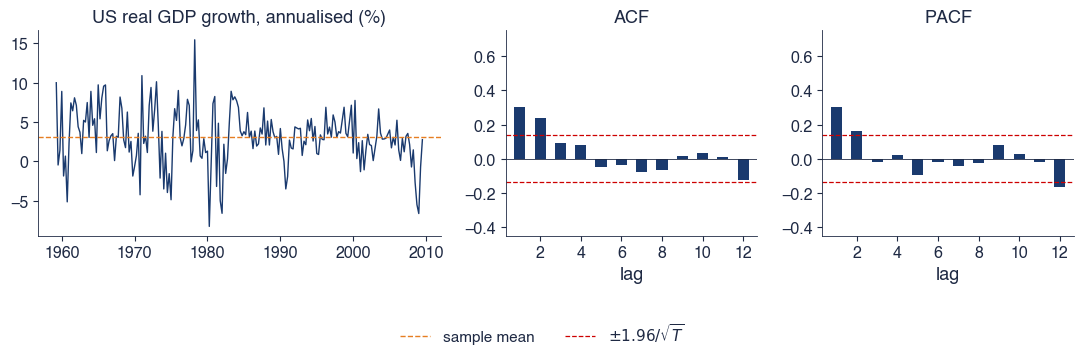

               AIC      BIC
ARMA(0,0)  1084.56  1091.17
ARMA(1,0)  1066.98  1076.91
ARMA(2,0)  1063.70  1076.93
ARMA(0,2)  1065.59  1078.83
ARMA(1,1)  1065.02  1078.25
BIC: ARMA(1,0)  AIC: ARMA(2,0)  LB: {'lb': 11.082552284473929, 'df': 7, 'lb_p': 0.13505844592463037}  JB p: 0.0003366741887768009
half-life (quarters): 0.5853923210418047


In [13]:
# Solution
b1 = b1_us_gdp(save=False)
print(pd.DataFrame({m: {'AIC': v['aic'], 'BIC': v['bic']} for m, v in b1['models'].items()}).T.round(2))
print('BIC:', b1['bic_best'], ' AIC:', b1['aic_best'], ' LB:', b1['lb'], ' JB p:', b1['jb_p'])
phi = b1['models']['ARMA(1,0)']['params'][1]
print('half-life (quarters):', np.log(0.5) / np.log(phi))

**Interpretation of the result.** BIC chooses AR(1) with $\hat\phi \approx 0.31$ (AIC: AR(2)); the residuals pass Ljung–Box. The half-life is below one quarter: shocks to the growth rate fade fast.

## B2 [Proposed]: Romanian real GDP growth

**Question.** Does Romanian quarterly real GDP growth have any ARMA structure? Model: B1.

1. Repeat the four steps of B1 for $y_t$ (`ro_gdp_growth('qoq')`).
2. Run Ljung–Box $Q^*(8)$ on the series itself.
3. Repeat the analysis without the four quarters of 2020, and compare.
4. Interpretation: why is the best forecast of next quarter's growth simply the mean?

**Report:** the chart, a table of ten criteria, the tests and two sentences.

In [ ]:
# Your code here


## B3 [Solved]: BET daily returns

**Question.** Is the first-order autocorrelation of BET returns useful for forecasting?

1. Estimate an AR(1) by maximum likelihood and report $\hat\phi$, its standard error and $t$-ratio, and $R^2$.
2. Test the residuals with Ljung–Box $Q^*(10)$ on 9 degrees of freedom, and the squared residuals with $Q^*(10)$.
3. Compute the kurtosis and the Jarque–Bera statistic of the residuals.
4. Forecast tomorrow's return with its 95% interval.
5. Interpretation: is the AR(1) coefficient statistically significant, and is it economically useful?

**Report:** six numbers, the chart, a forecast with its interval and two sentences.

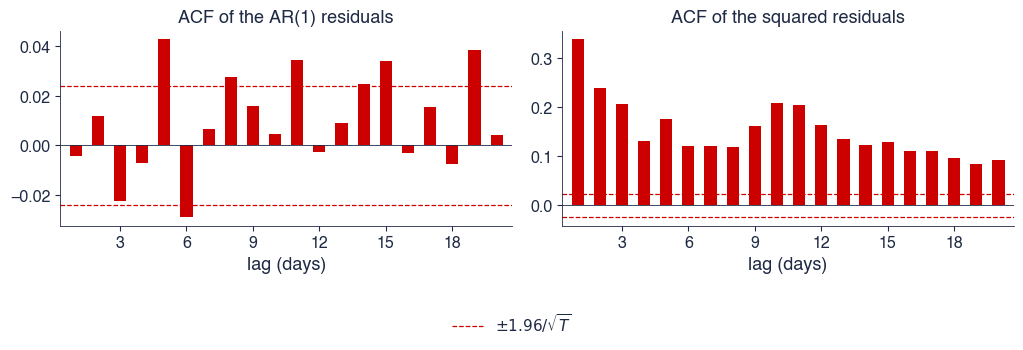

{'T': 6670,
 'last': '2026-09-18',
 'last_r': 2.172223412792995,
 'c': 0.06402769534272616,
 'phi': 0.10905347862005967,
 'se': 0.005220339506079938,
 't': 20.890112317991782,
 'sigma': 1.3902039381342157,
 'r2': 0.011869291740964849,
 'lb10': {'lb': 29.703270670048187, 'df': 9, 'lb_p': 0.0004927345557688182},
 'lbsq10': {'lb': 2495.872120326388, 'df': 10, 'lb_p': 0.0},
 'jb': 34128.34236092355,
 'jb_p': 0.0,
 'kurt': 14.028181079850897,
 'f1': 0.2939337719425904,
 'lo': -2.430815877966222,
 'hi': 3.0186834218514025,
 'mean': 0.06393125538818989}

In [15]:
# Solution
b3 = b3_returns('bet', fname='ch2_sem_b3', save=False)
b3

**Interpretation of the result.** $\hat\phi \approx 0.11$ with $t \approx 21$, but $R^2 \approx 1\%$: the forecast of tomorrow's return is tiny compared with its interval. The squared residuals are strongly autocorrelated (Chapter 5).

## B4 [Proposed]: EUR/RON daily returns

**Question.** Does the EUR/RON exchange rate behave like the BET? Model: B3.

1. Repeat the four steps of B3 (`b3_returns('eurron')`).
2. Compare $\hat\phi$, $R^2$ and the kurtosis with those of the BET.
3. Interpretation: why can a managed exchange rate show a larger first-order autocorrelation than a stock index?

**Report:** a table (two series, six numbers each) and two sentences.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: does an AR model beat simple forecasts of inflation?

**Question.** Is an AR(2) better than the historical mean and the last value at forecasting Romanian 12-month inflation one year ahead? Models: B1, A1.

1. At each origin (every month from January 2015), estimate an AR(2) on all data up to that month and forecast 12 months ahead.
2. Compute the same forecasts from the historical mean and from the last observed value.
3. Compare RMSE and MAE of the three methods, over the full period and before July 2021.
4. Interpretation: why do all three methods fail in 2022?

**Report:** a table of RMSE and MAE, the chart and a plan for a project.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant answered questions about the ARMA models of this seminar:

- (a) $X_t = 0.6X_{t-1} + 0.5X_{t-2} + \varepsilon_t$ is stationary because both coefficients are below 1;
- (b) an MA(1) with $\theta = 2$ is not stationary, because $|\theta| > 1$;
- (c) the AR(1) for BET returns has $t = 21$, so yesterday's return explains most of today's return;
- (d) for the residuals of an ARMA(1,1), Ljung–Box $Q(8)$ is compared with $\chi^2(8)$;
- (e) the forecast of an MA(2) three steps ahead equals the mean of the series;
- (f) in an AR(1), $X_t = c + \phi X_{t-1} + \varepsilon_t$, the mean of the series is $c$.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** six verdicts with one line of justification each.

In [ ]:
# Your code here
